In [17]:
import pandas as pd

In [18]:
import nltk

In [19]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [41]:
path = 'C:/Users/Administrator/Desktop/LDA/1_360.csv'

In [42]:
review = pd.read_csv(path)

In [43]:
only_review = review['review']
only_review.head()

0    Hyeopjae Beach is arguably the most picturesqu...
1     Nice views, nice place to take pictures, not ...
2     Don't judge, I know it was cold and all but w...
3     Beautiful beach in a hip area. Plenty of rent...
4     Very good for relax and some swimming (water ...
Name: review, dtype: object

In [44]:
from nltk.tokenize import RegexpTokenizer

In [24]:
tokenizer = RegexpTokenizer(r'\w+')

In [25]:
print(len(only_review))

51


In [26]:
only_review

0     Hyeopjae Beach is arguably the most picturesqu...
1      Nice views, nice place to take pictures, not ...
2      Don't judge, I know it was cold and all but w...
3      Beautiful beach in a hip area. Plenty of rent...
4      Very good for relax and some swimming (water ...
5     Wonderful beach in Jeju island. Very clear wat...
6      The beach by bus is easy to get to the bus st...
7     Car parking near the beach is a nightmare... t...
8      Water was very clear and sand was clean. Ther...
9     My girlfriend and I went for a walk here and s...
10    We visited this beautiful beach as part of the...
11     We go to Hyeopjae beach whenever in Jeju, lov...
12     Of the beaches we visited in Jeju, this one w...
13    The beach is nice with a combination of sand a...
14    Visited Monsanto cafe and found there are afew...
15     The colour of Hyeopjae beach is real. it is n...
16     One of the best beaches in Jeju, we loved thi...
17    Beautiful sand beach.Couldn't swim coz we 

In [27]:
# 토큰화
for idx in range(len(only_review)):
    only_review[idx] = only_review[idx].lower()
    only_review[idx] = tokenizer.tokenize(only_review[idx])

In [28]:
only_review

0     [hyeopjae, beach, is, arguably, the, most, pic...
1     [nice, views, nice, place, to, take, pictures,...
2     [don, t, judge, i, know, it, was, cold, and, a...
3     [beautiful, beach, in, a, hip, area, plenty, o...
4     [very, good, for, relax, and, some, swimming, ...
5     [wonderful, beach, in, jeju, island, very, cle...
6     [the, beach, by, bus, is, easy, to, get, to, t...
7     [car, parking, near, the, beach, is, a, nightm...
8     [water, was, very, clear, and, sand, was, clea...
9     [my, girlfriend, and, i, went, for, a, walk, h...
10    [we, visited, this, beautiful, beach, as, part...
11    [we, go, to, hyeopjae, beach, whenever, in, je...
12    [of, the, beaches, we, visited, in, jeju, this...
13    [the, beach, is, nice, with, a, combination, o...
14    [visited, monsanto, cafe, and, found, there, a...
15    [the, colour, of, hyeopjae, beach, is, real, i...
16    [one, of, the, best, beaches, in, jeju, we, lo...
17    [beautiful, sand, beach, couldn, t, swim, 

In [29]:
only_review = [[token for token in doc if len(token) > 1] for doc in only_review]

In [30]:
only_review = [[token for token in doc if not token.isnumeric()] for doc in only_review]

In [31]:
# 불용어 처리

import nltk
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize 

nltk.download('stopwords')
stop_words = set(stopwords.words('english')) 
stop_words.add('wa')
stop_words.add('it')
stop_words.add('don')
stop_words.add('if')
stop_words.add('also')
stop_words.add('little')
stop_words.add('great')
stop_words.add('another')
stop_words.add('no')
stop_words.add('everywhere')
stop_words.add('taking')
stop_words.add('the')
stop_words.add('took')
stop_words.add('part')
stop_words.add('however')
stop_words.add('made')
stop_words.add('after')
stop_words.add('u')
stop_words.add('one')

result = []
for idx, doc in enumerate(only_review):
    result.append([])
    for token in doc:
        if token not in stop_words:
            result[idx].append(token)
            #result.append(token)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [40]:
len(result)

51

In [39]:
f = open("for_wordcloud.txt", 'w')
for i in range(len(result)):
    for word in range(len(result[i])):
        f.write(result[i][word] + " ")
    f.write('\n')
f.close()

In [10]:
wordcloud = WordCloud().generate(text)


(-0.5, 399.5, 199.5, -0.5)

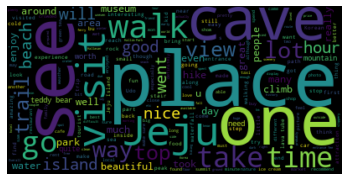

In [11]:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

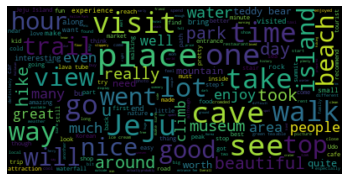

In [12]:
wordcloud = WordCloud(max_font_size=40).generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()